# Climate Change Data Analysis

Author: Tom Rowan, st20285213

## Introduction

Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

## Import Libraries

In [113]:
import os
import re
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
%matplotlib inline

In [114]:
# Import my utility library file
import utils
from utils import graph_colours as graph_colours

## Task 1 - Import and Preprocess Data Sets

Task 1:
- i.	Download the dataset from the above link. 
- ii.	Do the necessary preprocessing for example i.e., check for any null value or outlier. If found replace that with mean value and delete repeating factors as necessary.


Reference: https://databank.worldbank.org/reports.aspx?source=2&Topic=19#advancedDownloadOptions

Accessed: 10/05/2024

Reference: https://ourworldindata.org/world-region-map-definitions

Accessed:  15/05/2024



## Countries and Region Dataset

The World Bank provides a simple dataset which classifies each country by region. This data will be used to enrich analysis of the main datasets.

In [128]:
# To fetch via a URL, use varible: utils.countries_csv_url

# Load Data Set
countries_df = pd.read_csv('../datasets/countries/world-regions-according-to-the-world-bank.csv')
countries_df.drop('Year', axis=1)
countries_df.rename(columns={'World Region according to the World Bank': 'Region', 'Entity': 'Country'}, inplace=True)

# Produce Lists
countries = countries_df['Country'].unique()
countries.sort()
regions = countries_df['Region'].unique()
regions.sort()
country_codes = countries_df['Code'].unique()
# country_codes.sort() --> TypeError: '<' not supported between instances of 'str' and 'float' ???

print (f"Regions ({len(regions)}): {regions}")
print ()
print (f"Countries ({len(countries)}): {countries}")


Regions (7): ['East Asia and Pacific' 'Europe and Central Asia'
 'Latin America and Caribbean' 'Middle East and North Africa'
 'North America' 'South Asia' 'Sub-Saharan Africa']

Countries (217): ['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'British Virgin Islands'
 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon'
 'Canada' 'Cape Verde' 'Cayman Islands' 'Central African Republic' 'Chad'
 'Channel Islands' 'Chile' 'China' 'Colombia' 'Comoros' 'Congo'
 'Costa Rica' "Cote d'Ivoire" 'Croatia' 'Cuba' 'Curacao' 'Cyprus'
 'Czechia' 'Democratic Republic of Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'East Timor' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatin

To explore the relative size of the regions, I have performed a count and drawn a graph.

In [129]:
region_count_table = countries_df[['Country','Region']].groupby(['Region'])['Country'].count()
region_count_table

Region
East Asia and Pacific           37
Europe and Central Asia         58
Latin America and Caribbean     42
Middle East and North Africa    21
North America                    3
South Asia                       8
Sub-Saharan Africa              48
Name: Country, dtype: int64

'Jordan'

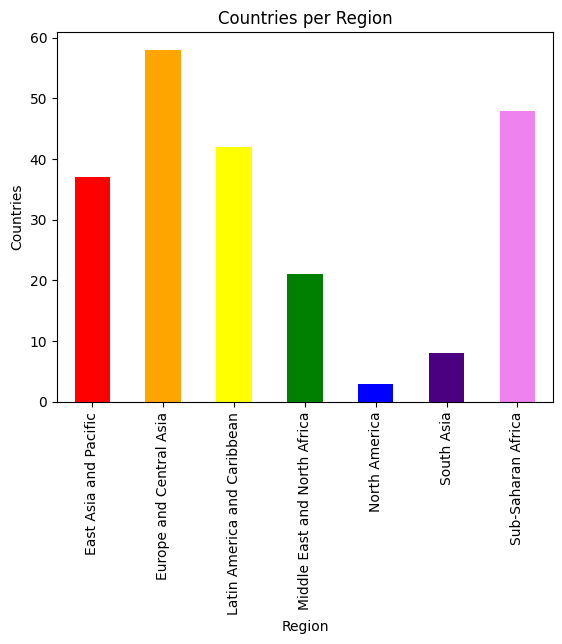

In [131]:
region_count_graph = region_count_table.plot(kind='bar', title='Countries per Region', color=graph_colours)
region_count_graph.set_xlabel('Region')
region_count_graph.set_ylabel('Countries')


Variables set in the above section:

| Variable Name | Elements | Type |
|--|--|--|
| countries_df | Country,Code,Region | Pandas DF |
| countries | Country Names | Array |
| regions | Region Names | Array |
| country_codes | Country Codes | Array |

## World Bank Development Indicator Data

I am attempting to explore how land usage affects climate change. The World Bank Development Indicators dataset includes use of land, electricity generation methods and volumes of CO2 produced by source.

In [135]:
# To fetch via a URL, use varible: utils.dev_indic_csv_url

# Load Data Set
devindic_df = pd.read_csv('../datasets/wbank_dev_indicators/38b7cb7a-172f-4be9-a48d-34d89fca9fc9_Data.csv')
devindic_df.head()


,Series Name,Series Code,Country Name,Country Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],...,2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Agricultural land (sq. km),AG.LND.AGRI.K2,Afghanistan,AFG,377940,377950,377900,378840,379280,379170,...,379100,379100,379100,379100,380100,380100,383130,383130,..,..
1,Agricultural land (sq. km),AG.LND.AGRI.K2,Albania,ALB,11440,11390,11400,11210,11220,10770,...,11742.9,11743,11817,11742.81,11740.81,11740,11655.55,11363.3,..,..
2,Agricultural land (sq. km),AG.LND.AGRI.K2,Algeria,DZA,400210,401090,398550,399057,411450,412110,...,414310,414564,413602,413351.408,413388.496,413160.71,413160.71,413160.71,..,..
3,Agricultural land (sq. km),AG.LND.AGRI.K2,American Samoa,ASM,22.7,23,23.3,23.6,23.9,24.2,...,26.9,27.2,27.5,27.8,28.1,28.4,28.7,29,..,..
4,Agricultural land (sq. km),AG.LND.AGRI.K2,Andorra,AND,230,227.5,228.5,228.6,228.1,218,...,188,188.1,188.2,188.2,188.34,188.001,187.773,187.562,..,..


This dataset is actually multiple tables of unrelated data concatenated, sharing the same column names. The Series Code is the key to each sub-table, each containing a complete set of records for each country. To confirm:

In [140]:
# Number of records per dataset, also number of countries
devindic_df.groupby(['Series Code'])['Country Name'].count().head()

Series Code
AG.LND.AGRI.K2    266
AG.LND.AGRI.ZS    266
AG.LND.ARBL.HA    266
AG.LND.ARBL.ZS    266
AG.LND.CREL.HA    266
Name: Country Name, dtype: int64

There are 266 Country Names in this dataset and 217 in the 'Countries' dataset. This will need to be reconciled so that each country in the DevIndic dataset can be assigned a region for further analysis.

To extract an individual sub table, the following example can be used:

In [143]:
df_AG_LND_AGRI_K2 = devindic_df.loc[devindic_df['Series Code'] == "AG.LND.AGRI.K2"]
df_AG_LND_AGRI_K2.head()

,Series Name,Series Code,Country Name,Country Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],...,2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Agricultural land (sq. km),AG.LND.AGRI.K2,Afghanistan,AFG,377940,377950,377900,378840,379280,379170,...,379100,379100,379100,379100,380100,380100,383130,383130,..,..
1,Agricultural land (sq. km),AG.LND.AGRI.K2,Albania,ALB,11440,11390,11400,11210,11220,10770,...,11742.9,11743,11817,11742.81,11740.81,11740,11655.55,11363.3,..,..
2,Agricultural land (sq. km),AG.LND.AGRI.K2,Algeria,DZA,400210,401090,398550,399057,411450,412110,...,414310,414564,413602,413351.408,413388.496,413160.71,413160.71,413160.71,..,..
3,Agricultural land (sq. km),AG.LND.AGRI.K2,American Samoa,ASM,22.7,23,23.3,23.6,23.9,24.2,...,26.9,27.2,27.5,27.8,28.1,28.4,28.7,29,..,..
4,Agricultural land (sq. km),AG.LND.AGRI.K2,Andorra,AND,230,227.5,228.5,228.6,228.1,218,...,188,188.1,188.2,188.2,188.34,188.001,187.773,187.562,..,..


In [156]:
#graph_data =df_AG_LND_AGRI_K2[['Country Name'],['2000 [YR2000]'],['2001 [YR2001]']]
graph_data =df_AG_LND_AGRI_K2[['2000 [YR2000]'],['2000 [YR2001]']] # <---- erroring!


#graph = graph_data.plot(kind='bar', title='Land Use', color=graph_colours)
#graph.set_xlabel('Region')
#graph.set_ylabel('Countries')

InvalidIndexError: (['2000 [YR2000]'], ['2000 [YR2001]'])

In [ ]:
series_codes = wbd['Series Code'].unique()
series_names = wbd['Series Name'].unique()

In [ ]:
titles = zip(series_names,series_codes)
print (set(titles))

In [ ]:
tbl_EN_ATM_CO2E_KT = wbd.loc[wbd['Series Code'] == "EN.ATM.CO2E.KT"]
tbl_AG_LND_TOTL_RU_K2 = wbd.loc[wbd['Series Code'] == "AG.LND.TOTL.RU.K2"]
tbl_EN_ATM_CO2E_KT

Variables set in the above section:

| Variable Name | Elements | Type |
|--|--|--|
| countries_df | Country,Code,Region | Pandas DF |
| countries | Country Names | Array |
| regions | Region Names | Array |
| country_codes | Country Codes | Array |

## Task 2 - Data Analysis


Task 2. Data analysis (LO2, LO3)
Formulate data analysis questions which could be answered by analysing your chosen dataset. For each question provide graph/chart along with your own interpretation. Please find the sample data analysis questions formulated for the ONS census dataset.

### Task Questions

- Describe the relationship between type of land use and CO2 emmissions, by country.
- Describe the change is land use by country, and by world region.
- Describe trends in land use.
- Predict how countries CO2 emmissions will trend.
